# Momentum reversal risk: a proof of concept

**What this is.** One narrow, working slice of a larger design, chosen to show the parts where
evidence can actually be produced. It runs offline in under a minute, needs no API key, and every
number is computed here or loaded from an artifact with the command that made it.

**What it covers.** The factor and its reversal record; a tail model tested against two baselines
with pre-registered pass conditions; what the book is carrying today; the one place a language
model reads a document, with its gates measured rather than claimed; the PM page; and the results
that failed.

**The discipline it runs under.** Every experiment in this repository is created in
`project/experiments.yaml` *before* it runs, with its hypothesis, prediction, method and **both**
outcome sentences frozen at that point. Choosing which experiments to run is legitimate and is
stated. Choosing which results to report is not.

In [1]:
import json, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
sys.path.insert(0, "../src")
ROOT = Path("..")
def art(p): return json.loads((ROOT / "reports" / p).read_text())

plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "figure.figsize": (9, 3.4)})
R1, R2, GREY = "#8c2f39", "#2f5d8c", "#9a9a9a"
print("ready")

ready


---
## 1 · The problem

**The exposure.** US equity cross-sectional momentum: on each month-end, rank the eligible
universe on its trailing twelve-month return skipping the most recent month, hold the top decile
long and the bottom decile short. Rebuilt monthly, measured daily.

**The event.** A ten-day factor return at or below **−432bp** — the 5th percentile of overlapping
ten-day returns from 1926 to 2022, frozen in advance and stored as a constant, not chosen here.

**The horizon.** Ten trading days.

**The user and the decision.** A discretionary macro PM who does not hold this book but whose
positions correlate with it. The decision is not *"is a crash coming"* — that is not forecastable
at this sample. It is **which macro theme the equity cross-section has already leaned into, how
hard, and how bad the next ten days could be if it unwinds.**

**Why severity and not probability.** Genuine crashes number in single figures in a century. Any
probability estimate would carry an interval wider than the estimate. A conditional quantile is
estimable from thousands of daily observations and is what the system reports.

In [2]:
from unstructured_momentum.data import french
from unstructured_momentum.pipeline import contract

wml = french.momentum()
print(f"French daily WML: {wml.index.min().date()} to {wml.index.max().date()}, {len(wml):,} days")
print(f"registered horizon : {contract.DECLARED_HORIZON_DAYS} trading days")
print(f"registered quantile: {contract.DECLARED_QUANTILE:.0%}")
print(f"registered level   : {contract.DECLARED_LEVEL*1e4:+.0f}bp   <- frozen, not fitted here")

French daily WML: 1926-11-03 to 2026-06-30, 26,173 days
registered horizon : 10 trading days
registered quantile: 5%
registered level   : -432bp   <- frozen, not fitted here


### The reversal record

Every episode the registered definitions admit, since 1926. This is the ground truth the rest of
the system is anchored to, and building it **refuted a claim the design was making** — see §6.

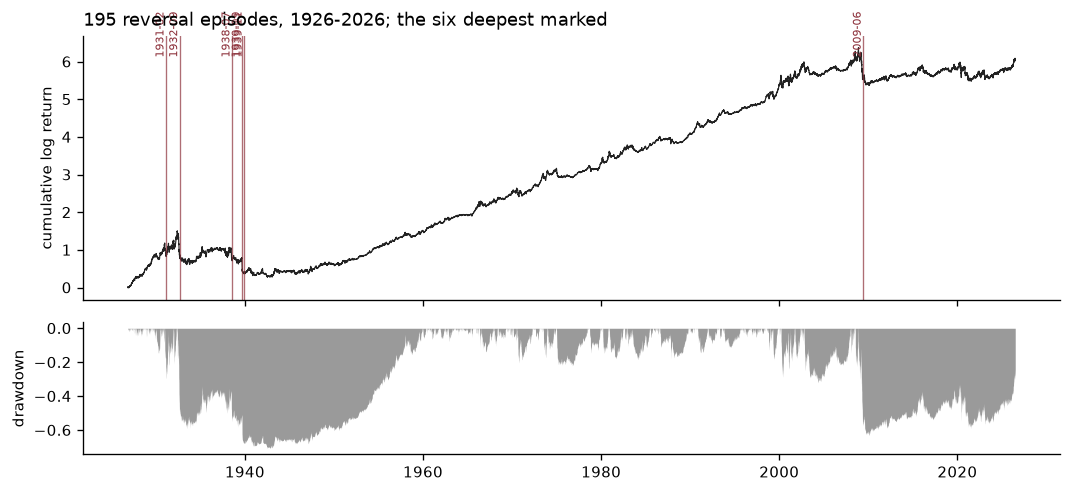

episodes admitted        195
deepest                  -52.0% on 1932-09-07
days at or below -933bp  3 episodes in a century


In [3]:
inv = pd.read_csv(ROOT/"reports/crash_inventory/inventory.csv", parse_dates=["trough_at"])
ci  = art("crash_inventory/summary.json")

fig, (ax, bx) = plt.subplots(2, 1, sharex=True, figsize=(9, 4.2),
                             gridspec_kw={"height_ratios": [2, 1]})
cum = (1 + wml).cumprod()
ax.plot(cum.index, np.log(cum), lw=.7, color="#222")
worst = inv.nsmallest(6, "depth")
for _, e in worst.iterrows():
    ax.axvline(e.trough_at, color=R1, lw=.8, alpha=.7)
    ax.annotate(str(e.trough_at.date())[:7], (e.trough_at, np.log(cum).max()*.97),
                fontsize=6.5, rotation=90, color=R1, ha="right")
ax.set_ylabel("cumulative log return")
ax.set_title(f"{ci['n_episodes']} reversal episodes, 1926-2026; the six deepest marked", loc="left")
dd = cum/cum.cummax() - 1
bx.fill_between(dd.index, dd, 0, color=GREY, lw=0)
bx.set_ylabel("drawdown"); plt.tight_layout(); plt.show()

print(f"episodes admitted        {ci['n_episodes']}")
print(f"deepest                  {inv.depth.min():.1%} on {inv.loc[inv.depth.idxmin(),'trough_at'].date()}")
print(f"days at or below -933bp  {int((inv.crash_days>0).sum())} episodes in a century")

---
## 2 · The tail model, against two baselines

**The question.** The design specifies a tail model with **no fitted parameters**: the 5% quantile
of past ten-day returns, each divided by the volatility at the time, taken over past starts in the
same state as today, times today's volatility. Does that beat the obvious alternatives?

Two published results motivate the two ingredients, and neither guarantees the answer:

- **Barroso & Santa-Clara**: scaling momentum by trailing volatility roughly doubles its Sharpe.
  That is a claim about the *second moment*, not about a 5% quantile.
- **Daniel & Moskowitz**: the worst losses cluster in high-volatility rebounds after bear markets.
  Conditioning on that state splits an already small tail sample.

Registered as **exp-084** before the script existed. Two comparisons, each with its own interval,
so neither can borrow the other's result.

Two things make the numbers honest:

1. **Every training target is realised.** The forward return from start *u* is known only at
   *u+10*, so training uses starts `u <= t-10`. Getting this wrong leaks returns from *after* the
   formation date into the quantile that forecasts it — worth 27bp on this series.
2. **Consecutive forecasts do not overlap.** Month-end formation, ten-day horizon, so the breach
   sequence is independent trials and Kupiec means what it says. An earlier run in this project
   treated 865 overlapping daily windows as independent and reported a failure that was the overlap.

In [4]:
# reproduce: uv run python scripts/poc_e1_tail.py
e1 = art("poc/e1_summary.json")
f  = pd.read_csv(ROOT/"reports/poc/e1_tail.csv", parse_dates=["formation"])

rows = []
for k, label in (("uncond","unconditional"), ("scaled","volatility-scaled"),
                 ("cond","scaled + bear state")):
    c = e1["coverage"][k]
    rows.append({"line": label, "breaches": c["breaches"], "of": c["n"],
                 "rate": f"{c['rate']:.2%}", "Kupiec p": f"{c['p']:.3f}",
                 "mean pinball": f"{e1['mean_pinball'][k]:.6f}"})
print(f"{e1['n_months']} monthly formation dates, {e1['first']} to {e1['last']}, "
      f"5% quantile at 10 days\n")
print(pd.DataFrame(rows).to_string(index=False))

1047 monthly formation dates, 1935-10-31 to 2022-12-30, 5% quantile at 10 days

               line  breaches   of  rate Kupiec p mean pinball
      unconditional        57 1047 5.44%    0.515     0.003868
  volatility-scaled        75 1047 7.16%    0.002     0.003311
scaled + bear state        75 1047 7.16%    0.002     0.003395


### The two registered verdicts

In [5]:
p = e1["primary_scaled_vs_uncond"]["12"]; s = e1["secondary_cond_vs_scaled"]["12"]
v = e1["verdict"]
print(f"PRIMARY   volatility scaling vs unconditional")
print(f"  pinball ratio {p['ratio']:.4f}   90% CI [{p['ci90'][0]:.4f}, {p['ci90'][1]:.4f}]"
      f"   -> {'PASS' if v['primary_passes'] else 'FAIL'}")
print(f"  scaling cuts the loss by {(1-p['ratio']):.1%}, and the interval excludes one.\n")
print(f"SECONDARY conditioning on the bear state, on top of scaling")
print(f"  pinball ratio {s['ratio']:.4f}   90% CI [{s['ci90'][0]:.4f}, {s['ci90'][1]:.4f}]"
      f"   -> {'PASS' if v['secondary_passes'] else 'FAIL'}")
print(f"  the interval excludes one on the WRONG SIDE: conditioning makes it worse.")
print(f"  Registered in advance: 'it splits the tail sample ... I would not be surprised to")
print(f"  see it fail'. It failed, and the fail sentence is what publishes.")

PRIMARY   volatility scaling vs unconditional
  pinball ratio 0.8561   90% CI [0.7864, 0.9277]   -> PASS
  scaling cuts the loss by 14.4%, and the interval excludes one.

SECONDARY conditioning on the bear state, on top of scaling
  pinball ratio 1.0252   90% CI [1.0046, 1.0457]   -> FAIL
  the interval excludes one on the WRONG SIDE: conditioning makes it worse.
  Registered in advance: 'it splits the tail sample ... I would not be surprised to
  see it fail'. It failed, and the fail sentence is what publishes.


### The finding that matters more than either verdict

Pooled coverage says the **unconditional** model is well calibrated (5.44%, Kupiec p = 0.515) and
the scaled model is not (7.16%, p = 0.002). That verdict is an artifact of averaging.

Split by volatility regime, the unconditional model breaches at **0.9% in calm months and 11.2% in
volatile ones**. Those two large errors, in opposite directions, cancel to something that passes a
pooled test. **A PM is never in the pooled sample — they are in one regime at a time.**

breach rate by volatility tercile (nominal 5%)

                    low vol mid vol high vol  spread
unconditional         0.86%   4.30%   11.17%  10.32%
volatility-scaled     7.74%   8.60%    5.16%   3.44%
scaled + bear state   7.74%   9.17%    4.58%   4.58%


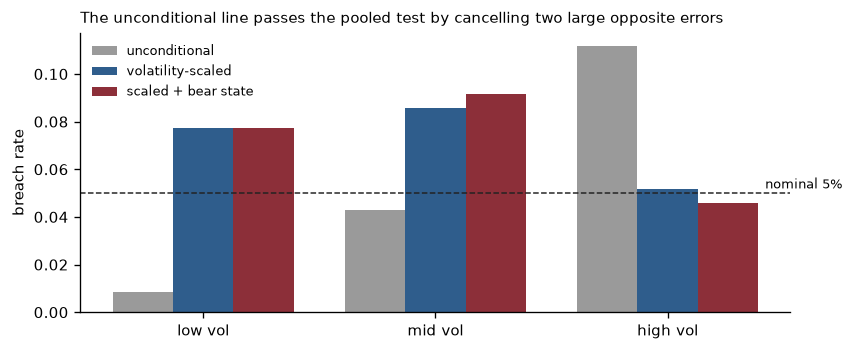

In [6]:
cc = e1["conditional_coverage"]
t = pd.DataFrame({k: cc[k]["by_vol_tercile"] for k in ("uncond","scaled","cond")}).T
t.index = ["unconditional", "volatility-scaled", "scaled + bear state"]
t["spread"] = [cc[k]["spread_across_terciles"] for k in ("uncond","scaled","cond")]
print("breach rate by volatility tercile (nominal 5%)\n")
print(pd.DataFrame({c: [f"{v:.2%}" for v in t[c]] for c in t.columns},
                   index=t.index).to_string())

fig, ax = plt.subplots(figsize=(7.2, 3))
x = np.arange(3); w = .26
for i,(k,lab,c) in enumerate([("uncond","unconditional",GREY),
                              ("scaled","volatility-scaled",R2),
                              ("cond","scaled + bear state",R1)]):
    ax.bar(x+(i-1)*w, [cc[k]["by_vol_tercile"][j] for j in t.columns[:3]], w, label=lab, color=c)
ax.axhline(.05, color="#222", ls="--", lw=.9); ax.text(2.42,.052,"nominal 5%",fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(t.columns[:3]); ax.set_ylabel("breach rate")
ax.legend(frameon=False, fontsize=7.5); ax.set_title(
    "The unconditional line passes the pooled test by cancelling two large opposite errors",
    loc="left", fontsize=9); plt.tight_layout(); plt.show()

### Can this comparison see an improvement at all?

A refutation is a claim about the world only once the instrument is shown able to detect the
effect it failed to find. So an improvement of exactly the right shape is planted: the scaled line
multiplied by the constant that brings its breach rate to the nominal 5%. That is a genuine
calibration fix and it leaves the conditioning intact.

*(A first attempt planted the wrong shape — shrinking toward the realised unconditional quantile,
a constant, which destroys the conditioning it is meant to improve. It was rebuilt before the
result was recorded.)*

In [7]:
pe = e1["planted_effect"]
print(f"multiplying the scaled line by {pe['calibrating_multiplier']:.3f} moves its breach rate")
print(f"from {e1['coverage']['scaled']['rate']:.2%} to {pe['breach_rate_after']:.2%} -- a real fix.\n")
for g in pe["grid"]:
    print(f"  {g['share_of_correction']:>4.0%} of the correction: pinball ratio {g['ratio']:.4f}"
          f"  CI [{g['ci90'][0]:.4f}, {g['ci90'][1]:.4f}]"
          f"  {'DETECTED' if g['detected'] else 'not detected'}")
print(f"\n  full correction: {pe['ratio']:.4f}  CI [{pe['ci90'][0]:.4f}, {pe['ci90'][1]:.4f}]"
      f"  -> {'DETECTED' if pe['detects_a_real_improvement'] else 'NOT DETECTED'}")

multiplying the scaled line by 1.158 moves its breach rate
from 7.16% to 5.06% -- a real fix.

   25% of the correction: pinball ratio 0.9954  CI [0.9904, 1.0008]  not detected
   50% of the correction: pinball ratio 0.9937  CI [0.9845, 1.0035]  not detected
  100% of the correction: pinball ratio 0.9963  CI [0.9784, 1.0157]  not detected

  full correction: 0.9963  CI [0.9782, 1.0165]  -> NOT DETECTED


**This is the most useful thing the experiment produced.** Pinball loss is the proper scoring rule
for a quantile and the one the design scores on. It **cannot see a fix that halves a two-point
coverage error** — the improvement is worth 0.4% of loss and the interval contains one.

So the loss function and the calibration diagnostic disagree about what matters, and only the
second is about what a reader of the page actually experiences. It also bounds the refutation
above: the secondary comparison resolved a 2.5% degradation, and **cannot rule out a small
benefit** from conditioning. That limit is the result, not a caveat on it.

### Two controls the result needed

**Is the scaling gain information, or arithmetic?** Dividing by a series and multiplying by its
current value could improve a loss for reasons that have nothing to do with the series knowing
anything. So the volatility series is **shuffled across time** — same distribution exactly,
alignment with returns destroyed — and the forecast rebuilt on it, 200 times.

**And did the design lose anything by dropping the fitted model?** The example page prints a
fitted quantile regression; the validation rests on the parameter-free estimator. Nothing had
compared them.

In [8]:
# reproduce: uv run python scripts/poc_e3_estimators.py
e3 = art("poc/e3_estimators.json"); A, B = e3["arm_a"], e3["arm_b"]
print("ARM A -- the negative control\n")
print(f"  real scaled forecast      ratio {A['real_ratio']:.4f}")
print(f"  shuffled volatility       median {A['shuffled_median']:.4f}   "
      f"5-95 band [{A['shuffled_band_5_95'][0]:.4f}, {A['shuffled_band_5_95'][1]:.4f}]")
print(f"  shuffles matching it      {A['share_of_shuffles_beating_the_real_gain']:.1%} of {A['n_shuffles']}\n")
print("  Shuffled, the forecast is WORSE than the unconditional quantile it is compared")
print("  against. The transformation alone carries nothing; the gain is the volatility")
print("  series knowing something about the date it scales.")

r = B["fitted_vs_parameter_free"]
print(f"\n\nARM B -- fitted regression against parameter-free, {B['n_common_dates']:,} dates\n")
print(f"  pinball ratio {r['ratio']:.4f}   90% CI [{r['ci90'][0]:.4f}, {r['ci90'][1]:.4f}]"
      f"  -> contains one; cannot be told apart on loss")
print(f"\n  {'estimator':<18}{'breach rate':>13}{'low vol':>10}{'high vol':>10}{'spread':>9}")
for k in ("parameter_free", "fitted"):
    c, cc = B["coverage"][k], B["conditional_coverage"][k]
    print(f"    {k:<16}{c['rate']:>13.4f}{cc['by_vol_tercile']['low vol']:>10.4f}"
          f"{cc['by_vol_tercile']['high vol']:>10.4f}{cc['spread']:>9.4f}")
print("\n  The parameter-free line is marginally more stable across regimes. That was")
print("  registered as reported-not-tested, carries no interval, and cannot break the tie.")

ARM A -- the negative control

  real scaled forecast      ratio 0.8561
  shuffled volatility       median 1.2085   5-95 band [1.1473, 1.2711]
  shuffles matching it      0.0% of 200

  Shuffled, the forecast is WORSE than the unconditional quantile it is compared
  against. The transformation alone carries nothing; the gain is the volatility
  series knowing something about the date it scales.


ARM B -- fitted regression against parameter-free, 1,047 dates

  pinball ratio 1.0075   90% CI [0.9766, 1.0350]  -> contains one; cannot be told apart on loss

  estimator           breach rate   low vol  high vol   spread
    parameter_free         0.0716    0.0774    0.0516   0.0344
    fitted                 0.0707    0.0716    0.0487   0.0430

  The parameter-free line is marginally more stable across regimes. That was
  registered as reported-not-tested, carries no interval, and cannot break the tie.


**Arm A passes emphatically** — 0% of 200 shuffles came near the real gain, and the shuffled
forecast is *worse* than the baseline it is compared against. The one clean positive result in
this notebook now has the negative control that every refutation in the register already had.

**Arm B settles the design question and unsettles the page.** Dropping the fitted model costs
nothing measurable, so the simplification is vindicated on *parsimony*, not on performance — a
weaker and more accurate defence than asserting the parameter-free model is better.

But the two estimators disagree by **4.2 percentage points on the single date the example page
reports**: −9.47% fitted against −13.69% parameter-free, with a realised −9.56%. One line is
breached; the other is not. The page's headline rests on a choice a century of data cannot
resolve, so **the page now prints both** rather than picking one and staying quiet about it.

**What this says for the page.** The volatility-scaled quantile is the one to print: it cuts
pinball loss by 14% and its breach rate varies by 3.4 points across regimes against the
unconditional model's 10.3. It is uniformly about two points too shallow — a level offset, and a
stated limitation — where the alternative is wrong in opposite directions depending on the regime
the PM happens to be in. **Bear-state conditioning does not earn its place and is not used.**

---
## 3 · The same model on the book we would actually hold

Everything above is French's published factor. A PM does not hold that: they hold a book. So the
book was rebuilt from point-in-time Russell 3000 holdings — top and bottom deciles on 12-1,
**value-weighted within each leg**, dollar-neutral, rebuilt monthly — and the same four lines
were scored on it.

The point of this section is that **the answer changes**, and in the direction that matters.

In [9]:
b = pd.read_parquet(ROOT/"data/processed/book_returns.parquet")
meta = art("poc/book_returns_meta.json")
print(f"{len(b):,} daily returns, {b.index[0].date()} to {b.index[-1].date()}, "
      f"{b['formation'].nunique()} formations")
print(f"correlation with French's published factor: "
      f"{meta['corr_daily_vs_french']:.3f} daily, {meta['corr_monthly_vs_french']:.3f} monthly\n")
print("It tracks the published factor without being it: same sort, a narrower universe,")
print("value weighting inside deciles rather than 30/70 breakpoints. That gap is the point --")
print("a book is more concentrated than a factor, and concentration is what tails are made of.")

2,997 daily returns, 2014-02-03 to 2026-08-19, 144 formations
correlation with French's published factor: 0.880 daily, 0.834 monthly

It tracks the published factor without being it: same sort, a narrower universe,
value weighting inside deciles rather than 30/70 breakpoints. That gap is the point --
a book is more concentrated than a factor, and concentration is what tails are made of.


In [10]:
e5 = art("poc/e5_book_tail_summary.json")
cov = e5["coverage"]
print(f"out of sample on the book, {e5['n_months']} formation months "
      f"{e5['first']} to {e5['last']}, 5% VaR at 10 trading days:\n")
print(f"  {'line':<26}{'breaches':>9}{'rate':>9}{'Kupiec p':>11}   verdict")
NAME = {"uncond":"unconditional", "scaled":"volatility-scaled",
        "state":"+ calendar state", "terc":"+ volatility tercile"}
for k in ("uncond", "scaled", "state", "terc"):
    c = cov[k]
    print(f"  {NAME[k]:<26}{c['breaches']:>6} /{c['n']:<3}{100*c['rate']:8.2f}%"
          f"{c['p']:11.3f}   {'passes' if c['p'] > 0.10 else 'FAILS'}")
r = e5["vs_uncond"]["scaled"]
print(f"\n  pinball vs unconditional {r['ratio']:.3f}, "
      f"90% block-bootstrap CI [{r['ci90'][0]:.3f}, {r['ci90'][1]:.3f}]")

out of sample on the book, 81 formation months 2015-09-30 to 2022-12-31, 5% VaR at 10 trading days:

  line                       breaches     rate   Kupiec p   verdict
  unconditional                  9 /81    11.11%      0.028   FAILS
  volatility-scaled              6 /81     7.41%      0.352   passes
  + calendar state               6 /81     7.41%      0.352   passes
  + volatility tercile           6 /81     7.41%      0.352   passes

  pinball vs unconditional 0.890, 90% block-bootstrap CI [0.752, 1.061]


**The coverage verdict inverts on the book.** On French's factor the unconditional line was
adequate; on the book it **fails** (11.11%, p = 0.028) where the volatility-scaled line
**passes** (7.41%, p = 0.352). A model validated on the published factor and deployed on a real
book would have been calibrated on the wrong object.

Two disciplines are visible in that table and both cut against the result being oversold:

- the **pinball interval includes one**. Scaling earns its place on *coverage*, not on loss, and
  the number is printed with its interval rather than without it;
- the two conditioned lines **breach on exactly the same formations** as the scaled line. Adding
  a calendar state or a volatility tercile changes nothing, so neither is used. A conditioner
  that does not move the forecast is not a feature, and three of them were tested before that
  sentence could be written.

---
## 4 · What the book is carrying

A momentum sort does not know *why* a stock rose; it collects whatever drove returns over the
ranking window. So the book arrives holding a macro bet nobody chose. This measures which one, by
comparing the real book's loadings against **500 random books matched on leg size and
capitalisation** — the sort is the only thing that differs, so the z-score is attributable to it.

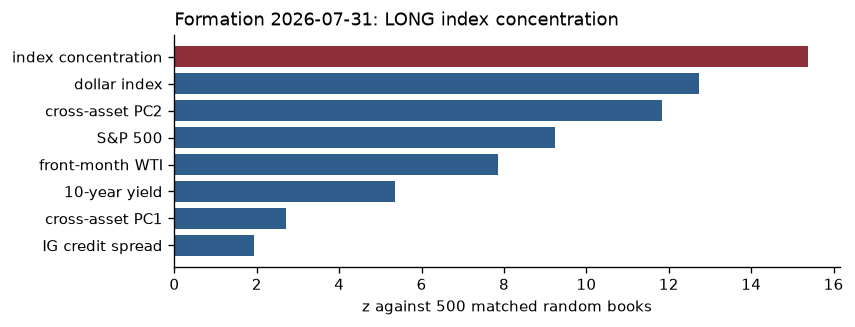

winner leg, ten largest by index weight:
  AMD  AMAT  LRCX  CAT  KLAC  MRVL  DELL  GLW  VRT  HPE

Read the ORDERING, not the level. 6 of 8 series clear the family
threshold, which is why the eight-series test was retired as saturated. Against the
same-rule null this sort's median maximum is 23.8; today's is
15.4, so the book is quieter than a typical month.


In [11]:
b = art("current_book.json"); srn = art("same_rule_null.json")
z = pd.Series(b["z"]).sort_values(ascending=False)
LBL = {"mkt":"S&P 500","d10y":"10-year yield","wti":"front-month WTI","usd":"dollar index",
       "ig":"IG credit spread","concentration":"index concentration","pc1":"cross-asset PC1",
       "pc2":"cross-asset PC2"}
fig, ax = plt.subplots(figsize=(7.2, 2.8))
ax.barh([LBL[k] for k in z.index][::-1], z.values[::-1],
        color=[R1 if k==z.index[0] else R2 for k in z.index][::-1])
ax.set_xlabel("z against 500 matched random books")
ax.set_title(f"Formation {b['as_of']}: {b['direction']} {LBL[z.index[0]]}", loc="left")
plt.tight_layout(); plt.show()

print("winner leg, ten largest by index weight:")
print("  " + "  ".join(b["winner_top10"]))
print(f"\nRead the ORDERING, not the level. {int((z>2.74).sum())} of 8 series clear the family")
print(f"threshold, which is why the eight-series test was retired as saturated. Against the")
print(f"same-rule null this sort's median maximum is {srn['median_z']['12-1']:.1f}; today's is")
print(f"{z.max():.1f}, so the book is quieter than a typical month.")

### That z depends on a convention nobody stated

The chart above is **equal-weighted** across the names in each leg. The design specifies
**value-weighting within each leg**, and five separate measurement paths in this package had
drifted to `.mean(axis=1)` without saying so (trap trp-92). Running the same names both ways is
the whole of exp-090.

In [12]:
e6 = art("poc/e6_summary.json")
# market_value, not weight_pct: the panel's weight column rounds to 0.00 for 1,184 of 2,683
# names (trap trp-91), so quantity x price is the honest weighting source. Both are stored.
L = e6["latest"]["market_value"]
print(f"the same names, the same date ({e6['latest_formation_date']}), "
      f"the same {e6['n_draws_requested']} matched books:\n")
print(f"  {'series':<16}{'z equal':>9}{'rank':>6}  |{'z value':>9}{'rank':>6}")
for k, v in sorted(L.items(), key=lambda kv: -kv[1]["z_equal"]):
    star = "  <--" if k == "concentration" else ""
    print(f"  {k:<16}{v['z_equal']:9.2f}{v['rank_equal']:6d}  |{v['z_value']:9.2f}"
          f"{v['rank_value']:6d}{star}")
m = e6["membership"]["per_leg"]
print(f"\n  the two constructions are not even the same book: Jaccard "
      f"{m['winners']['jaccard_median']:.3f} winners, {m['losers']['jaccard_median']:.3f} losers,")
print(f"  a median {m['losers']['median_names_differing']:.0f} names differing on a leg of "
      f"{m['losers']['median_leg_size']:.0f}.")

the same names, the same date (2026-07-31), the same 500 matched books:

  series            z equal  rank  |  z value  rank
  concentration       18.90     1  |     1.50     7  <--
  usd                 13.58     2  |     8.67     1
  pc2                 12.09     3  |     4.34     4
  mkt                  9.31     4  |     6.03     2
  wti                  7.94     5  |     5.54     3
  d10y                 4.31     6  |     3.23     5
  pc1                  2.27     7  |    -0.91     8
  ig                   1.80     8  |     2.18     6

  the two constructions are not even the same book: Jaccard 0.675 winners, 0.695 losers,
  a median 43 names differing on a leg of 244.


**This is why the concentration reading is never printed as a discovered exposure.** Index
concentration is the *largest* loading of the eight when the legs are equal-weighted and the
*seventh of eight* when they are value-weighted, as the design specifies. Nothing about the book
changed between those two lines — only a convention that had never been written down.

The mechanism is visible in the placebo: under value weighting a handful of mega-caps dominate
every book, real or random, so the sort stops being the only thing that differs and the z
collapses. exp-090 is registered as a **sensitivity analysis, not a hypothesis test**, and no
p-value is claimed for the difference.

The rule this bought: **a concentration figure is quoted with its weighting in the same sentence
or it is not quoted.** That holds in the memo, in this notebook, and on the page.

---
## 5 · The one place a model reads a document

Returns and holdings identify the loser leg's exposure. They cannot say what condition three
hundred distressed businesses **share**. Filings can, and that is the seat the language model is
asked to earn.

**Four constraints, enforced in code rather than asserted:**

| risk | the rule |
|---|---|
| models invent evidence | every record carries a **verbatim span, string-matched against the source**; an unmatched span drops the record and is counted |
| models guess when unsure | a **mandatory decline path** — "no stated condition" is a first-class answer |
| models emit numbers that cannot be checked | the **schema has no numeric field**, so no probability or severity can be returned |
| documents postdate the book | **acceptance-time gating**: nothing read could postdate the formation date |

In [13]:
lo = pd.read_parquet(ROOT/"reports/gate2/nov2020_extractions.parquet")
wi = pd.read_parquet(ROOT/"reports/gate2/nov2020_extractions_winner.parquet")
def rates(d):
    ok = d[d.get("error").isna()] if "error" in d else d
    st = ok[ok.states_a_condition.fillna(False)]
    return dict(read=len(ok), stated=len(st), rate=len(st)/len(ok),
                declined=(len(ok)-len(st))/len(ok),
                grounded=st.quote_grounded.fillna(False).mean())
L, W = rates(lo), rates(wi)
print(f"formation 2020-10-31, filings accepted BEFORE that date\n")
print(f"{'':22}{'loser leg':>12}{'winner leg':>12}")
for k, lab in (("read","filings read"), ("stated","states a condition"),
               ("rate","  as a rate"), ("declined","declined"), ("grounded","quote gate: grounded")):
    fmt = (lambda v: f"{v:>12,}") if k in ("read","stated") else (lambda v: f"{v:>11.1%} ")
    print(f"  {lab:<20}{fmt(L[k])}{fmt(W[k])}")
print(f"\nextraction errors: {len(lo)-L['read']} of {len(lo)}")
print("\nA reader that declines four in five is behaving. One that never declines is guessing.")

formation 2020-10-31, filings accepted BEFORE that date

                         loser leg  winner leg
  filings read                 112         206
  states a condition            20          12
    as a rate               17.9%        5.8% 
  declined                  82.1%       94.2% 
  quote gate: grounded      95.0%       91.7% 

extraction errors: 0 of 112

A reader that declines four in five is behaving. One that never declines is guessing.


### The finding the design predicted, 52 days early

The loser leg was airlines, cruise lines and cinemas — priced on **one** condition. United
Airlines named it, and named the event that would resolve it, in a filing the regulator accepted on
**9 September 2020**, two months before the vaccine announcement.

In [14]:
g = lo[lo.states_a_condition.fillna(False) & lo.quote_grounded.fillna(False)]
r = g[g.ticker.eq("UAL") & g.quote.str.contains("vaccine|treatment", case=False)].iloc[0]
print(f"{r.ticker}   accepted {str(r.accepted_at)[:19]}   accession {r.accession}")
print(f"condition: {r.condition}\n")
import textwrap; print(textwrap.fill(f'"{r.quote.strip()}"', 96, initial_indent="  ",
                                     subsequent_indent="  "))
print(f"\n{g.ticker.nunique()} loser names carry a stated condition; the sector screen sees")
print(f"10 GICS sectors and reads DIVERSIFIED. The filings see one bet.")

UAL   accepted 2020-09-09 11:00:27   accession 0001104659-20-103243
condition: widely accepted treatment and/or vaccine for COVID-19

  "expects demand to remain suppressed and plateau at levels of around 50%, relative to 2019
  levels, until a widely accepted treatment and/or vaccine for COVID-19 is widely available"

9 loser names carry a stated condition; the sector screen sees
10 GICS sectors and reads DIVERSIFIED. The filings see one bet.


### Where does the model beat a rule?

The memo asserts the model reads a filing more faithfully than a keyword rule. That cannot be
settled by comparing them to each other — the model's labels are not ground truth, so agreement
would only show a rule can imitate it. Precision and recall need hand labels, which are reserved
and unlabelled, and are **not** substituted for here.

So both readers are scored on a criterion **neither chose and neither can see**: does their rate
separate formation dates that preceded a reversal from dates that did not, using the crash
inventory's own classification, registered long before either was scored?

The rule is written out in full in the registration, derived from the **extractor's own
instructions** rather than from any look at its output, so it is a fair rule and not a straw man.

In [15]:
# reproduce: uv run python scripts/poc_e2_keyword_vs_model.py
e2 = art("poc/e2_summary.json"); a = e2["agreement"]
print(f"{e2['n_filings']:,} filings, {e2['n_dates']} dates "
      f"({e2['model']['n_episode']} preceding an episode, {e2['model']['n_control']} not)\n")
print(f"{'reader':<10}{'episode':>10}{'control':>10}{'gap':>9}{'p':>9}   verdict")
for k in ("model", "keyword"):
    s_ = e2[k]
    print(f"  {k:<8}{s_['median_episode']:>10.3f}{s_['median_control']:>10.3f}"
          f"{s_['gap']:>+9.3f}{s_['p_one_sided']:>9.4f}   "
          f"{'SEPARATES' if s_['separates'] else 'does not separate'}")
print("\nNeither clears. The registered power statement says the honest sentence is that this")
print("comparison could not tell the two readers apart -- not that they are the same.")

3,625 filings, 28 dates (12 preceding an episode, 16 not)

reader       episode   control      gap        p   verdict
  model        0.106     0.094   +0.013   0.2083   does not separate
  keyword      0.438     0.426   +0.012   0.5278   does not separate

Neither clears. The registered power statement says the honest sentence is that this
comparison could not tell the two readers apart -- not that they are the same.


**Neither reader separates.** That was the third of three registered outcomes and the one I
thought least likely. Under the registration it also means the earlier design-tier text result
does not survive being recomputed on the inventory's classification — which is more permissive
than the registry troughs that result used, admitting episodes with a median depth of −6.1%. That
is an explanation of the disagreement, **not a defence of the earlier number**, and both are
reported.

What the comparison *did* establish is the mechanism the registration predicted, quantified:

In [16]:
print(f"the rule fires on {100*(a['both']+a['keyword_only'])/a['n']:.1f}% of filings; "
      f"the model on {100*(a['both']+a['model_only'])/a['n']:.1f}% -- 3.7x as often\n")
print(f"{'':16}{'model YES':>12}{'model NO':>12}")
print(f"  {'keyword YES':<14}{a['both']:>12,}{a['keyword_only']:>12,}")
print(f"  {'keyword NO':<14}{a['model_only']:>12,}{a['neither']:>12,}")
print(f"\nOf the {a['both']+a['keyword_only']:,} filings the rule flags, the model declines "
      f"{a['keyword_only']:,} and keeps {100*a['of_what_the_keyword_flags_the_model_keeps']:.1f}%.")
print("Almost all the disagreement runs one way. That is the boilerplate a rule keyed on")
print("conditional language fires on -- measured, not asserted. It is NOT precision: which of")
print("those declines are right needs the hand labels, and they are reserved.")

the rule fires on 43.2% of filings; the model on 12.1% -- 3.7x as often

                   model YES    model NO
  keyword YES            341       1,224
  keyword NO              96       1,964

Of the 1,565 filings the rule flags, the model declines 1,224 and keeps 21.8%.
Almost all the disagreement runs one way. That is the boilerplate a rule keyed on
conditional language fires on -- measured, not asserted. It is NOT precision: which of
those declines are right needs the hand labels, and they are reserved.


### Why there is no precision or recall number anywhere in this notebook

Both readers' rates are **rates**, not accuracies. Turning them into precision and recall needs
labels produced independently of the model, and that measurement is **recorded as blocked, not
deferred** (`exp-087`).

The author cannot be the annotator: the author wrote the extraction prompt, so author labels
measure agreement with the prompt's own definition rather than with the construct, and there is
no second annotator to bound the noise. What it needs is a paid annotation pool — a crowd
platform with a qualification round and gold controls, or a contracted analyst — with **two
independent annotators per item and an agreement statistic reported before any precision figure
is quoted**. That is a procurement line on the production path.

The alternative, one person labelling a hundred sentences and calling the result precision, would
be a **worse artifact than the absence**, because it would look like a measurement.

What *can* be done without annotators is to construct the truth instead of buying it — which is
the next section.

### Constructing the truth instead of buying it

A condition span the model already extracted from one filing is a real statement, in a real
filer's words. Inject it into a **different** filing the model *declined* — different company,
different date, **same sector** so it is plausible for its host — and you have a document whose
correct answer is known exactly. Run it the other way with real forward-looking boilerplate,
which the instructions explicitly exclude, and you have documents whose correct answer is *no*.

**The control is what makes any of it readable.** Every host was declined on the committed run,
but the reader is not deterministic, so the baseline is not zero — it is whatever a fresh read of
the same document does with nothing added. The first two versions of this experiment lacked that
control and their recall numbers had no denominator.

In [17]:
# reproduce: uv run python scripts/poc_e4_planted.py
e4 = art("poc/e4_summary.json")
c, m, k = e4["control_unplanted_reread"], e4["model"], e4["keyword"]
ml = m["recall_on_planted_conditions"] - c["flag_rate"]
kl = k["recall_on_planted_conditions"] - c["keyword_flag_rate"]

print(f"{'':38}{'model':>10}{'keyword rule':>15}")
print(f"  {'same docs, NOTHING planted':<36}{c['flag_rate']:>10.1%}{c['keyword_flag_rate']:>15.1%}")
print(f"  {'a real condition planted':<36}{m['recall_on_planted_conditions']:>10.1%}"
      f"{k['recall_on_planted_conditions']:>15.1%}")
print(f"  {'LIFT from the plant':<36}{ml:>+10.1%}{kl:>+15.1%}")
print(f"  {'quotes the planted span':<36}{m['span_localisation']:>10.1%}{'n/a':>15}")
print(f"  {'stays declined on boilerplate':<36}"
      f"{m['specificity_on_planted_boilerplate']:>10.1%}{k['specificity_on_planted_boilerplate']:>15.1%}")
print(f"\n  run-to-run stability: {1-c['flag_rate']:.1%} of declined filings stay declined")
print(f"  on a fresh read of identical text.")

                                           model   keyword rule
  same docs, NOTHING planted                1.7%          46.7%
  a real condition planted                 19.2%          54.2%
  LIFT from the plant                     +17.5%          +7.5%
  quotes the planted span                  17.5%            n/a
  stays declined on boilerplate            97.5%          62.5%

  run-to-run stability: 98.3% of declined filings stay declined
  on a fresh read of identical text.


**My registered prediction was refuted.** I predicted the model would flag ≥70% of planted
conditions and localise ≥60%. It flags 19.2% and localises 17.5%. It is far more conservative
than I expected.

**But the rule's apparent recall advantage is a base rate.** It flags 54.2% of planted documents
— and 46.7% of the very same documents *unplanted*. Measured as a response to the thing actually
added, the model lifts **+17.5 points** against the rule's **+7.5**. It reacts more than twice as
strongly to a real condition while flagging almost nothing when nothing was there.

**On specificity it is not close**: given real boilerplate, the model stays declined 97.5% of the
time, the rule 62.5%.

So the model's contribution is **discrimination, not sensitivity** — and that is now measured,
with no annotator, against truth that was built rather than bought.

**Two earlier versions of this experiment were wrong, and both are kept in the register.** The
first drew plants at random and put an FDA nerve-graft sentence into a cruise line's filing;
declining that is *correct*, so the ground truth was invalid. It did produce an incidental
finding — the model rejects a topically foreign splice 83% of the time and the rule 37% — from a
broken design, reported as such. The second added sector matching and still had no control.

**And one difference is not a score at all.** The rule flags a *document*. It cannot say what the
filer is priced on. The condition text and the verbatim span that reach the page — United Airlines
naming a vaccine as the condition on 2020-09-09 — have no keyword equivalent, and no rank test
measures that.

That is the honest state of the AI-adds-value claim: **a capability difference that is real and
visible, and a performance difference this comparison could not resolve.**

### And the pipeline that was supposed to supply the theme

Everything above is a *document-level* extractor answering one question of one filing. The
design's own claim is bigger: that the companies carrying a named exposure component state, in
their filings, **one shared risk theme that random books do not**. None of that pipeline existed,
so exp-091 built it — Ledoit-Wolf on the market residual, three sign-fixed components, a bridge,
an encoder, HDBSCAN over UMAP, 200 cell-matched random books per date as the placebo — and ran it
on eleven registered dates plus the memo date. Nothing was skipped.

Its verdict is **instrument-limited**, which is neither of the two outcomes the registration
anticipated.

In [18]:
e7 = art("poc/e7_summary.json"); c = e7["counts"]
print(f"encoder {e7['encoder']}   classifier trained: {e7['classifier_run']}\n")
print(f"  episode dates                       {c['episode_dates']}")
print(f"  ...where a theme rose above placebo {c['episode_theme_risen']}   "
      f"(registered prediction: at least 5)")
print(f"  ...carrying an expected label       {c['episode_dates_with_expected_label_registered']}"
      f"   (written into the registration before the run)")
print(f"  ...that matched it                  {c['episode_risen_theme_label_matches']}\n")
print(f"  calm windows                        {c['calm_dates']}, of which {c['calm_built']} build")
lab = e7["expected_label_check"]
print(f"\n{lab['headline']}")

encoder sentence-transformers/all-MiniLM-L6-v2   classifier trained: False

  episode dates                       8
  ...where a theme rose above placebo 2   (registered prediction: at least 5)
  ...carrying an expected label       3   (written into the registration before the run)
  ...that matched it                  0

  calm windows                        3, of which 2 build

0 of 3 episode dates with a registered expected label matched it. The rule was never actually exercised: the 2 dates where a theme rose (2019-08-31, 2020-12-31) are not among the 3 dates that carry an expected label (2020-10-31, 2022-10-31, 2025-03-31), so the intersection is empty and no match was reachable. The zero is a property of which dates were labelled, not evidence that the labels were wrong.


In [19]:
print("the control side is not weak, it is empty:\n")
for d in e7["dates"]:
    if d["kind"] != "calm": continue
    if not d["built"]:
        print(f"  {d['date']}  DOES NOT BUILD  {d['reasons'][0][:64]}...")
    else:
        cov = next(r for r in e7["per_date_table"] if r["date"] == d["date"])
        print(f"  {d['date']}  builds, but component sets hold "
              f"{cov['set_companies_with_item_1a']} covered companies of {cov['set_size']}")
print("\n  A component set with no covered company cannot produce a non-zero excess weight.")
print("  So 'no theme rose on the calm windows' is arithmetic, not evidence, and the")
print("  eight-against-three comparison has a control side that could not have gone the")
print("  other way. That is what decides the verdict.")

the control side is not weak, it is empty:

  2016-08-31  builds, but component sets hold [0, 0, 0] covered companies of 137
  2017-08-31  DOES NOT BUILD  holdings panel holds only 22 observations in the 126-day window;...
  2018-08-31  builds, but component sets hold [0, 1, 0] covered companies of 135

  A component set with no covered company cannot produce a non-zero excess weight.
  So 'no theme rose on the calm windows' is arithmetic, not evidence, and the
  eight-against-three comparison has a control side that could not have gone the
  other way. That is what decides the verdict.


Three things are worth taking from this rather than from a cleaner result.

**The zero label matches is not what it looks like.** Only three episode dates carry an expected
label, and the two dates where a theme *did* rise are not among them — so no match was ever
reachable. The registered rule was never actually exercised. That is a property of which dates
were labelled, not evidence about the labels, and saying "0 of 8" would have implied a test that
did not happen.

**The clusterer is not stable on the flagship date.** Three independent 64-company draws from
2020-10-31's own filings, at identical parameters and the same seed, returned 2, 2 and 26
clusters. A declared degeneracy flag fires on that date and on no other — the one date the page
is built for.

**The binding constraint is named and quantified.** Across twelve dates the component set holds
between 0 and 25 companies with a point-in-time Item 1A against set sizes of 116 to 137. What
would move this is not a better model, it is coverage: point-in-time Item 1A for the whole set
rather than the fifth of it a free corpus reaches. That is a specific production item, not a
general lament, and it is why the page prints the 8-K reading instead — by a fallback rule fixed
before either result was seen.

---
## 6 · The example output

The PM page for that formation date. **Every number on it is produced by a registered field**
carrying its value, the artifact that produced it, and the command that regenerates that artifact;
a tokeniser then fails the build on any numeral in the prose matching neither a computed field nor
a declared definitional constant.

That check was built after it was discovered the page had been **hand-typed** — the numbers were
right, and nothing would have noticed when one stopped being right.

In [20]:
prov = art("poc/page_2020-10-30.provenance.json")
print(f"numerals on the page {prov['numerals']}   distinct {prov['distinct']}"
      f"   registered fields {prov['registered_fields']}   canary "
      f"{'PASS' if prov['passes'] else 'FAIL'}\n")
print((ROOT/"reports/poc/page_2020-10-30.txt").read_text())

numerals on the page 74   distinct 52   registered fields 55   canary PASS

──────────────────────────────────────────────────────────────────────────────
MOMENTUM REVERSAL RISK — formation 2020-10-31 (last session 2020-10-30)
US equity cross-sectional momentum, the reconstructed 12-1 book:
top and bottom deciles of the Russell 3000, VALUE-WEIGHTED within each leg.
Horizon: 10 trading days at the 5% quantile. The probability line below is the VaR
restated at the event threshold, not a forecast of a reversal's timing.
──────────────────────────────────────────────────────────────────────────────

SEVERITY   [the parameter-free scaled quantile; no conditioning state]
  10-day 5% VaR      -19.29%     against an unconditional -7.57%   (2.5x)
  10-day 5% ES      -31.93%
  the book's trailing volatility is 60.9% annualised, and the estimator is today's
  volatility times the 5% quantile of past scaled returns. Nothing is fitted.
  P(10-day return at or below the book's own unconditional -7.5

### Clicking a number

The provenance file is what makes that page traceable evidence rather than a claim about
traceability. It is also where the most recent instrument fault was found (trap trp-97).

In [21]:
segs = [x for x in prov["segments"] if x.get("field")]
amb = [x for x in segs if x["field"].get("ambiguous")]
print(f"{len(segs)} numeral occurrences on the page, each carrying its own field.\n")
for t in ("-19.29%", "17.0%", "0.146"):
    f = next((x["field"] for x in segs if x["text"] == t and not x["field"].get("ambiguous")), None)
    if f:
        print(f"  {t:<9} {f['label']}\n            {f['source']}\n            {f['reproduce']}")

print(f"\n  and {len(amb)} occurrences say they CANNOT be resolved:")
a = amb[0]
print(f"    {a['text']!r} -> {len(a['field']['candidates'])} registered fields render this text")
for cnd in a["field"]["candidates"]:
    print(f"        - {cnd['label']}")
print("\n  These used to carry whichever field was registered last: the values were right,")
print("  the labels on repeated numerals were not, and the canary passed throughout because")
print("  it asks whether a numeral matches a field, not which one. A provenance layer may")
print("  say 'I cannot tell'; it may not guess.")
print("\n  Here the ambiguity IS the result: at this date the scaled and unconditional lines")
print("  breach on the same formations, so they print the same rate and the same p-value.")

74 numeral occurrences on the page, each carrying its own field.

  -19.29%   10-day 5% VaR, scaled line
            reports/poc/e5_book_tail.csv
            uv run python scripts/poc_e5_book_tail.py
  17.0%     the rate
            reports/gate2/nov2020_extractions.parquet
            uv run python scripts/gate2_extract.py loser
  0.146     sector Herfindahl
            data/raw/ishares/IWV/panel
            uv run python scripts/gate2_nov2020.py

  and 9 occurrences say they CANNOT be resolved:
    '9.26%' -> 2 registered fields render this text
        - its breach rate
        - the unconditional line's breach rate

  These used to carry whichever field was registered last: the values were right,
  the labels on repeated numerals were not, and the canary passed throughout because
  it asks whether a numeral matches a field, not which one. A provenance layer may
  say 'I cannot tell'; it may not guess.

  Here the ambiguity IS the result: at this date the scaled and unconditional li

### And what actually happened next

The page is written standing on 2020-10-30 and none of what follows was available to it. It is
printed under its own heading, fenced, because an example output that never shows its own outcome
asks the reader to take the machinery on trust.

realised over 2020-11-02 to 2020-11-13 (10 sessions): -14.58%

  var_uncond     -7.57%   BREACHED
  var_scaled    -19.29%   not breached

  2020-11-09: book -20.21%  =  winners -4.18%, losers +16.03%
  French's published factor over the same window: -9.56%


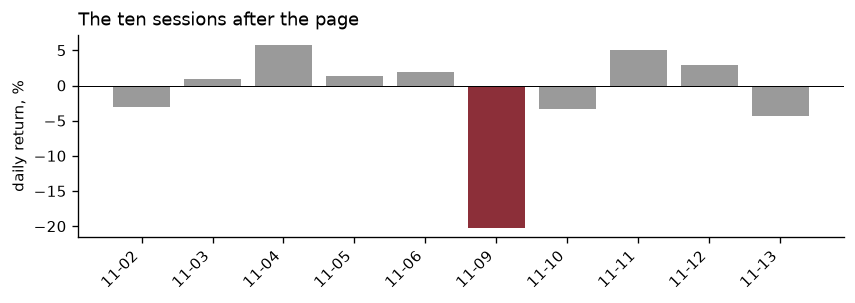

In [22]:
rz = art("poc/realised_2020-10-30.json")
w = rz["worst_session"]
print(f"realised over {rz['window']['start']} to {rz['window']['end']} "
      f"({rz['window']['sessions']} sessions): {100*rz['realised_return']:+.2f}%\n")
L = rz["against_the_lines_the_page_printed"]
for k in ("var_uncond", "var_scaled"):
    print(f"  {k:<12} {100*L[k]['level']:+7.2f}%   "
          f"{'BREACHED' if L[k]['breached'] else 'not breached'}")
print(f"\n  {w['date']}: book {100*w['book']:+.2f}%  =  winners {100*w['winner_leg']:+.2f}%, "
      f"losers {100*w['loser_leg']:+.2f}%")
print(f"  French's published factor over the same window: "
      f"{100*rz['french_reference']['compounded_over_the_same_window']:+.2f}%")

fig, ax = plt.subplots(figsize=(7.2, 2.6))
path = pd.Series({pd.Timestamp(x["date"]): x["r"] for x in rz["daily_path"]})
ax.bar(range(len(path)), 100*path.values,
       color=[R1 if v < -0.05 else GREY for v in path.values])
ax.set_xticks(range(len(path)))
ax.set_xticklabels([d.strftime("%m-%d") for d in path.index], rotation=45, ha="right")
ax.set_ylabel("daily return, %")
ax.set_title("The ten sessions after the page", loc="left")
ax.axhline(0, color="k", lw=0.6)
plt.tight_layout(); plt.show()

The loss is **the short half**: the loser leg rose 16% in a session while the winner leg fell 4%.
That is the mechanism the page had named in advance, under *what would change this reading* — a
vaccine or treatment readout resolving the shared condition and repricing the loser leg upward
together — sourced to UAL stating it as the condition on 2020-09-09, seven weeks before the
formation.

**And it still proves nothing about the model.** One formation is one observation. The realised
loss is worse than the unconditional line and inside the volatility-scaled one, which is
consistent with the coverage result in section 3 and would be equally consistent with luck. The
evidence for the scaled line is 81 formations of coverage testing, not this one. A package that
showed this outcome as validation would be doing exactly what it spends the rest of its length
warning against.

---
## 7 · What failed

The honest measure of a process is what it caught and what it killed. Three results below are
failures, and each one changed the design.

In [23]:
import yaml
exps = yaml.safe_load((ROOT/"project/experiments.yaml").read_text())
traps = yaml.safe_load((ROOT/"project/traps.yaml").read_text())
done = [e for e in exps if e.get("status") == "complete"]
from collections import Counter
c = Counter(e.get("verdict") for e in done)
print(f"{len(exps)} experiments registered, {len(done)} complete, {len(traps)} instrument faults logged\n")
for k, n in c.most_common(): print(f"  {k:<20}{n}")

91 experiments registered, 77 complete, 97 instrument faults logged

  supported           32
  refuted             23
  inconclusive        9
  instrument_limited  8
  underpowered        5


**The three that killed something.**

| result | what it did |
|---|---|
| The three-route framework does not partition the record — **44.6%** of episodes fit no route against a registered band of 5–30%, and 77 of the 86 fail identically | **retired the route classification rule.** The spec's retirement note quotes the number |
| Route 3 triggered on **0 of 195** episodes, with a planted synthetic case recovered correctly so the zero is about the record, not the instrument | **retired the Route 3 detector** |
| The text elevation holds at design tier (**p = 0.0175**) and **does not reproduce** on the sealed holdout (**p = 0.4686**) | exp-077 is recorded as design tier only, and is kept, not deleted |

And in this notebook: **bear-state conditioning failed its registered test** and is not used.

A counterfactual that would rescue the first result — dropping the bear-state clause moves 71 of
the 77 into Route 1 — is **reported and not applied**. A rule amended after seeing which clause
failed is fitted, not registered.

---
## 8 · Limitations, stated once

- **Filing coverage is partial and skewed large.** 1,579 tickers against a universe near 2,900,
  and the micro-cap wreckage where the loser-leg mechanism concentrates is systematically absent.
  Coverage loss depresses the episode dates more than the controls, so the measured gap is a
  **floor on the true one, not a ceiling**.
- **Crowding is inferred from returns, not measured.** Public data cannot see positioning before
  it moves prices. Two positioning channels are refuted with certified minimum detectable effects
  rather than quietly dropped. Prime-broker positioning is the first item on the production path.
- **No probability of a reversal is reported.** Three episodes in a century contain a crash day.
- **The tail model is about two points too shallow** in every volatility regime. That is a level
  offset and it is disclosed rather than fitted away.
- **The text result is design-tier only.** It did not reproduce out of sample at n = 6 episodes.
- **This notebook is one slice.** The theme pipeline, the positioning overlap and the catalyst
  calendar are designed and not built; the memo carries the full design and the production path.

**Production path, in one line:** a point-in-time equity master, commercial transcripts for
coverage, and prime-broker positioning — which is what decides whether crowded exits can be seen
before prices move rather than after.